# 鸢尾花分类：第一个完整机器学习项目

**适合人群：** 已学过 Python 基础，希望通过完成项目理解机器学习流程的初学者。

**你需要会：** 变量、列表、函数和基础 Python 语法。不要求提前掌握机器学习。

**项目目标：** 根据花萼和花瓣的 4 个测量值，预测鸢尾花属于 3 个品种中的哪一个。

**完成标准：** 能加载数据、探索数据、划分训练集、训练模型、评估效果、预测新样本并保存模型。

## 项目路线

1. 导入工具并加载数据
2. 理解数据和目标
3. 可视化特征
4. 划分训练集和测试集
5. 建立并训练基准模型
6. 评估模型
7. 预测新样本并保存模型
8. 完成练习和项目总结

In [1]:
# 导入本项目需要的工具
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("pandas 版本：", pd.__version__)
print("scikit-learn 版本：", sklearn.__version__)

pandas 版本： 1.5.3
scikit-learn 版本： 1.2.2


## 1. 加载数据

鸢尾花数据集随 `scikit-learn` 提供，不需要下载。每一行代表一朵花，4 个特征分别是花萼长度、花萼宽度、花瓣长度和花瓣宽度。

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

print(f"数据共有 {df.shape[0]} 行、{df.shape[1]} 列")
df.head()

数据共有 150 行、6 列


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. 理解数据

机器学习前先回答三个问题：数据是否有缺失值、各类别是否平衡、特征的取值范围是什么。

In [3]:
summary = pd.DataFrame({
    "数据类型": df.dtypes.astype(str),
    "缺失值数量": df.isna().sum(),
    "不同值数量": df.nunique(),
})
summary

,数据类型,缺失值数量,不同值数量
sepal length (cm),float64,0,35
sepal width (cm),float64,0,23
petal length (cm),float64,0,43
petal width (cm),float64,0,22
target,int32,0,3
species,object,0,3


In [4]:
print("各品种样本数量：")
display(df["species"].value_counts())

print("特征统计：")
df[iris.feature_names].describe().round(2)

各品种样本数量：


setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

特征统计：


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


**观察：** 数据没有缺失值，3 个品种各有 50 条记录，类别是平衡的，因此暂时不需要填补缺失值或处理类别不平衡。

## 3. 可视化特征

散点图可以帮助我们观察不同品种是否容易区分。这里只看花瓣长度和花瓣宽度，避免图表过于复杂。

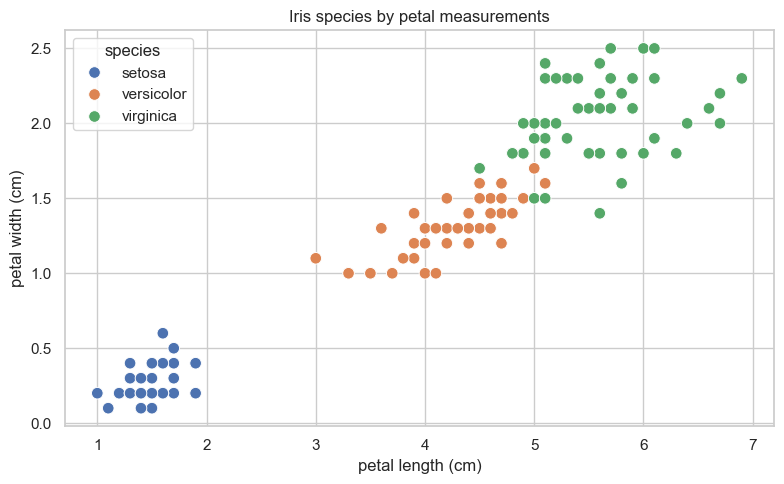

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=70,
)
plt.title("Iris species by petal measurements")
plt.tight_layout()
plt.show()

**观察：** `setosa` 与其他品种明显分开；`versicolor` 和 `virginica` 有少量重叠，因此模型可能会在这两个品种之间产生错误。

## 4. 划分训练集和测试集

- `X` 是模型用来判断的 4 个特征。
- `y` 是模型要预测的品种编号。
- 训练集用于学习，测试集只在最后评估。

`stratify=y` 保证训练集和测试集中各品种的比例一致。

In [6]:
X = df[iris.feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("训练集大小：", X_train.shape)
print("测试集大小：", X_test.shape)

训练集大小： (120, 4)
测试集大小： (30, 4)


## 5. 建立并训练模型

我们使用逻辑回归作为第一个分类模型。`Pipeline` 会先标准化特征，再训练模型。这样可以确保标准化只从训练数据中学习，避免数据泄漏。

In [7]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=500)),
])

model.fit(X_train, y_train)
print("模型训练完成")

模型训练完成


## 6. 评估模型

准确率表示预测正确的样本比例。分类报告提供每个品种的精确率、召回率和 F1 分数；混淆矩阵显示具体错在了哪里。

In [8]:
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"测试集准确率：{test_accuracy:.2%}\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names,
))

测试集准确率：93.33%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



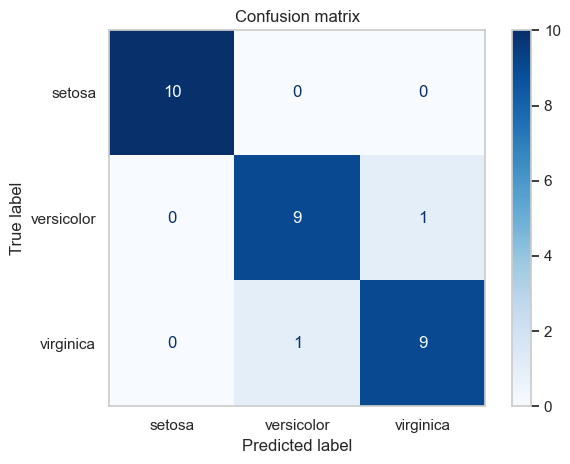

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap="Blues",
)
plt.title("Confusion matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

### 用交叉验证检查稳定性

单次划分可能碰巧容易或困难。5 折交叉验证会进行 5 次不同的训练和验证，让结果更可靠。测试集仍然没有参与这一步。

In [10]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
print("每一折准确率：", cv_scores.round(3))
print(f"平均准确率：{cv_scores.mean():.2%}")
print(f"标准差：{cv_scores.std():.3f}")

每一折准确率： [0.917 0.958 0.958 0.958 1.   ]
平均准确率：95.83%
标准差：0.026


## 7. 预测新样本

下面模拟收到一朵新花的 4 个测量值。模型会输出品种以及三个品种各自的预测概率。

In [11]:
new_flower = pd.DataFrame(
    [[5.9, 3.0, 5.1, 1.8]],
    columns=iris.feature_names,
)

predicted_class = model.predict(new_flower)[0]
probabilities = model.predict_proba(new_flower)[0]

print("预测品种：", iris.target_names[predicted_class])
pd.Series(probabilities, index=iris.target_names, name="预测概率").to_frame().round(3)

预测品种： virginica


,预测概率
setosa,0.004
versicolor,0.314
virginica,0.682


## 8. 保存模型

保存后，下次可以直接加载模型进行预测，不必重新训练。

In [12]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "iris_logistic_regression.joblib"
joblib.dump(model, model_path)

print("模型已保存到：", model_path.resolve())

模型已保存到： C:\Users\86157\Documents\学习系统\output\jupyter-notebook\iris-classification-project\models\iris_logistic_regression.joblib


## 练习

把下面 `your_flower` 中的 4 个数字换成你自己的数值，然后在运行前猜测模型会预测哪个品种。

In [13]:
# 练习答案框架：修改数字并运行
your_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names,
)
your_prediction = model.predict(your_flower)[0]
print("模型预测：", iris.target_names[your_prediction])

模型预测： setosa


## 常见错误与改进方向

**常见错误：** 在划分训练集之前对全部数据进行标准化，会让测试集信息提前进入训练流程。这里使用 `Pipeline` 避免了这个问题。

**当前局限：** 数据集只有 150 条记录，而且非常整洁，不能代表真实项目中的脏数据。

**下一步：** 尝试决策树或随机森林并比较交叉验证结果，或者把预测功能做成一个简单网页。

## 项目结论

本项目完成了一个可重复运行的监督学习分类流程：加载数据、探索数据、拆分数据、预处理、训练、评估、交叉验证、预测新样本和保存模型。

提交项目时可以重点说明：为什么需要独立测试集、为什么使用 Pipeline、模型在哪些品种之间容易出错，以及当前数据集的局限。